In [2]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
#load data and do basic exploration
df = pd.read_csv('Data_04_Property_Purchase_Decision_Dataset.csv')
df.head()

,property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
0,25002,UK,Birmingham,Townhouse,Fully-Furnished,2862,1141712,2005,0,5,...,70950,585272,30,2580,556440,0.05,10,4,1,1
1,25003,India,Chennai,Townhouse,Semi-Furnished,5642,848469,2002,5,4,...,5684,566190,20,3131,282279,0.74,5,7,8,0
2,25004,UK,Birmingham,Independent House,Semi-Furnished,2275,910391,2004,2,3,...,52695,766145,20,9245,144246,0.11,9,6,4,1
3,25005,Brazil,São Paulo,Studio,Fully-Furnished,4333,866338,2012,5,2,...,25290,487135,20,5085,379203,0.14,6,10,2,0
4,25006,Brazil,São Paulo,Independent House,Semi-Furnished,3365,675228,1960,0,3,...,4190,276407,25,7670,398821,0.45,5,5,3,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_id              25000 non-null  int64  
 1   country                  25000 non-null  str    
 2   city                     25000 non-null  str    
 3   property_type            25000 non-null  str    
 4   furnishing_status        25000 non-null  str    
 5   property_size_sqft       25000 non-null  int64  
 6   price                    25000 non-null  int64  
 7   constructed_year         25000 non-null  int64  
 8   previous_owners          25000 non-null  int64  
 9   rooms                    25000 non-null  int64  
 10  bathrooms                25000 non-null  int64  
 11  garage                   25000 non-null  int64  
 12  garden                   25000 non-null  int64  
 13  crime_cases_reported     25000 non-null  int64  
 14  legal_cases_on_property  25000 no

In [5]:
#check for null values
df.isnull().sum()

property_id                0
country                    0
city                       0
property_type              0
furnishing_status          0
property_size_sqft         0
price                      0
constructed_year           0
previous_owners            0
rooms                      0
bathrooms                  0
garage                     0
garden                     0
crime_cases_reported       0
legal_cases_on_property    0
customer_salary            0
loan_amount                0
loan_tenure_years          0
monthly_expenses           0
down_payment               0
emi_to_income_ratio        0
satisfaction_score         0
neighbourhood_rating       0
connectivity_score         0
decision                   0
dtype: int64

In [6]:
#drop property ID
df.drop('property_id', axis = 1, inplace= True)

In [7]:
#check for duplicates
df[df.duplicated()]

,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,bathrooms,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision


In [8]:
#exploring furnishing status and encoding
Counter(df['furnishing_status'])

#ordinal encoding
from sklearn.preprocessing import OrdinalEncoder
t_encoder = OrdinalEncoder(categories=[['Unfurnished', 'Semi-Furnished', 'Fully-Furnished']])
df['furnishing_encoded'] = t_encoder.fit_transform(df[['furnishing_status']])

print(Counter(df['furnishing_encoded']))
print(Counter(df['furnishing_status']))

Counter({0.0: 8458, 1.0: 8290, 2.0: 8252})
Counter({'Unfurnished': 8458, 'Semi-Furnished': 8290, 'Fully-Furnished': 8252})


In [9]:
df['property_type'].unique()

<StringArray>
['Townhouse', 'Independent House', 'Studio', 'Apartment', 'Villa',
 'Farmhouse']
Length: 6, dtype: str

In [10]:
#exploring property type
Counter(df['property_type'])

from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder(categories=[['Studio', 'Apartment', 'Independent House', 'Townhouse',   'Villa', 'Farmhouse']])
df['property_type_encoded'] = ordinal_encoder.fit_transform(df[['property_type']])

print(Counter(df['property_type']))
print(Counter(df['property_type_encoded']))

Counter({'Townhouse': 4224, 'Apartment': 4213, 'Independent House': 4185, 'Studio': 4173, 'Villa': 4113, 'Farmhouse': 4092})
Counter({3.0: 4224, 1.0: 4213, 2.0: 4185, 0.0: 4173, 4.0: 4113, 5.0: 4092})


In [11]:
#exploring Country and cities

print(df['country'].unique())
print(df['city'].unique())

#merging city and country for locatoin

df['location'] = df['country'] +  "_" + df['city']
df['location'].unique()

#onehotencoding location

from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output= False)
encoded_location = ohe.fit_transform(df[['location']])
encoded_location = pd.DataFrame(encoded_location, columns= ohe.get_feature_names_out() )
encoded_location



<StringArray>
[          'UK',        'India',       'Brazil',          'UAE',
       'Canada', 'South Africa',       'France',        'Japan',
        'China',          'USA',    'Australia',    'Singapore',
      'Germany']
Length: 13, dtype: str
<StringArray>
[    'Birmingham',        'Chennai',      'São Paulo',      'Abu Dhabi',
       'Montreal',      'Cape Town',         'Mumbai',           'Lyon',
          'Osaka',          'Delhi',        'Toronto',   'Johannesburg',
       'Shanghai',          'Tokyo',        'Houston',          'Kyoto',
  'San Francisco',        'Beijing',      'Melbourne', 'Rio de Janeiro',
      'Vancouver',          'Dubai',      'Singapore',         'Munich',
       'Shenzhen',         'Sydney',    'Los Angeles',         'London',
      'Frankfurt',         'Berlin',      'Liverpool',       'Brisbane',
       'New York',      'Marseille',           'Pune',          'Paris',
      'Hyderabad',     'Manchester',        'Chicago',      'Bangalore']
Length:

,location_Australia_Brisbane,location_Australia_Melbourne,location_Australia_Sydney,location_Brazil_Rio de Janeiro,location_Brazil_São Paulo,location_Canada_Montreal,location_Canada_Toronto,location_Canada_Vancouver,location_China_Beijing,location_China_Shanghai,...,location_UAE_Dubai,location_UK_Birmingham,location_UK_Liverpool,location_UK_London,location_UK_Manchester,location_USA_Chicago,location_USA_Houston,location_USA_Los Angeles,location_USA_New York,location_USA_San Francisco
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
24997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  25000 non-null  str    
 1   city                     25000 non-null  str    
 2   property_type            25000 non-null  str    
 3   furnishing_status        25000 non-null  str    
 4   property_size_sqft       25000 non-null  int64  
 5   price                    25000 non-null  int64  
 6   constructed_year         25000 non-null  int64  
 7   previous_owners          25000 non-null  int64  
 8   rooms                    25000 non-null  int64  
 9   bathrooms                25000 non-null  int64  
 10  garage                   25000 non-null  int64  
 11  garden                   25000 non-null  int64  
 12  crime_cases_reported     25000 non-null  int64  
 13  legal_cases_on_property  25000 non-null  int64  
 14  customer_salary          25000 no

<Axes: xlabel='location', ylabel='Count'>

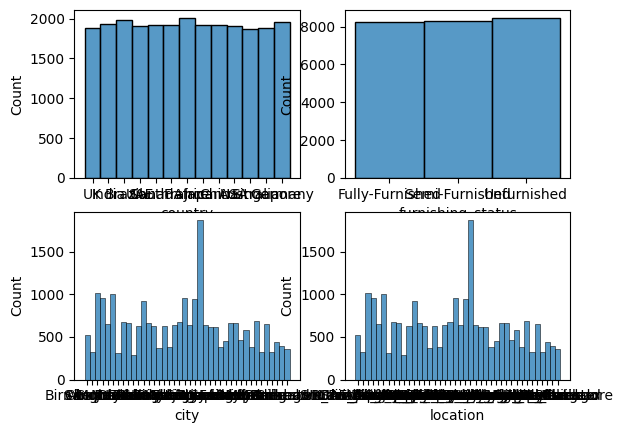

In [12]:
#exloring categorical variables
df.info()
plt.Figure(figsize=(20,15))
plt.subplot(2,2,1)
sns.histplot(df['country'])

plt.subplot(2,2,2)
sns.histplot(df['furnishing_status'])

plt.subplot(2,2,3)
sns.histplot(df['city'])

plt.subplot(2,2,4)
sns.histplot(df['location'])

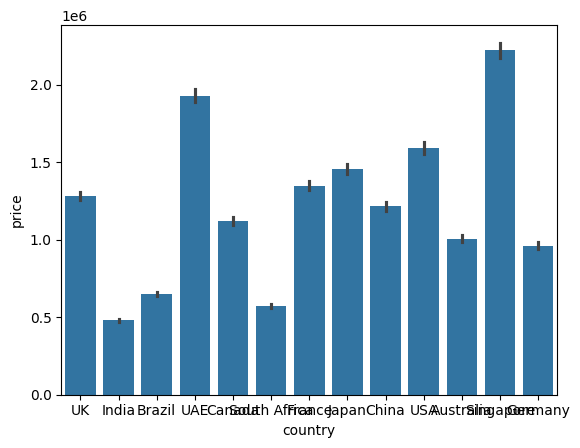

In [13]:
#which country has most expensive properties
plt.Figure(figsize=(100,200))
sns.barplot(x= 'country', y = 'price', data = df)
plt.show()

In [ ]:
#dropping encoded columns
df.drop(['country',	'city'	,'property_type', 'furnishing_status'], axis= 1, inplace= True)

In [ ]:
#merge encoded columns